In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load data
df = pd.read_csv('../data/raw/online_retail_II.csv', 
                  encoding='latin1',
                  parse_dates=['InvoiceDate'])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Unique countries: {df['Country'].nunique()}")

Dataset shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5942
Unique products: 5305
Unique countries: 43


In [16]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing > 0])

Missing values:
Description      4382
Customer ID    243007
dtype: int64


In [17]:
df = df.dropna(subset=['Customer ID'])
df = df[df['Customer ID'] != 0]
print(f"After dropping null customers: {df.shape}")


After dropping null customers: (824364, 8)


In [ ]:
print(f"Cancellations: {df[df['Quantity'] < 0].shape[0]} rows")

# Remove cancellations for sales analysis
df_sales = df[df['Quantity'] > 0].copy()
print(f"Sales only: {df_sales.shape}")

Cancellations: 18744 rows
Sales only: (805620, 8)


In [19]:
df_sales['TotalPrice'] = df_sales['Quantity'] * df_sales['Price']

# Remove unrealistic prices (outliers)
Q1 = df_sales['TotalPrice'].quantile(0.25)
Q3 = df_sales['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
df_sales = df_sales[(df_sales['TotalPrice'] >= Q1 - 1.5*IQR) & 
                     (df_sales['TotalPrice'] <= Q3 + 1.5*IQR)]

print(f"After outlier removal: {df_sales.shape}")

After outlier removal: (739238, 9)


In [20]:
df_sales['Year'] = df_sales['InvoiceDate'].dt.year
df_sales['Month'] = df_sales['InvoiceDate'].dt.month
df_sales['Day'] = df_sales['InvoiceDate'].dt.day
df_sales['Hour'] = df_sales['InvoiceDate'].dt.hour
df_sales['DayOfWeek'] = df_sales['InvoiceDate'].dt.dayofweek
df_sales['IsWeekend'] = df_sales['DayOfWeek'].isin([5,6]).astype(int)

In [21]:
daily_sales = df_sales.groupby('InvoiceDate')['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

# Resample to daily if needed
daily_sales = daily_sales.set_index('ds').resample('D').sum().reset_index()

In [22]:
df_sales.to_csv('../data/processed/cleaned_sales.csv', index=False)
daily_sales.to_csv('../data/processed/daily_sales.csv', index=False)

print("Data cleaning complete!")
print(f"Final shape: {df_sales.shape}")
print(f"Daily sales shape: {daily_sales.shape}")

Data cleaning complete!
Final shape: (739238, 15)
Daily sales shape: (739, 2)


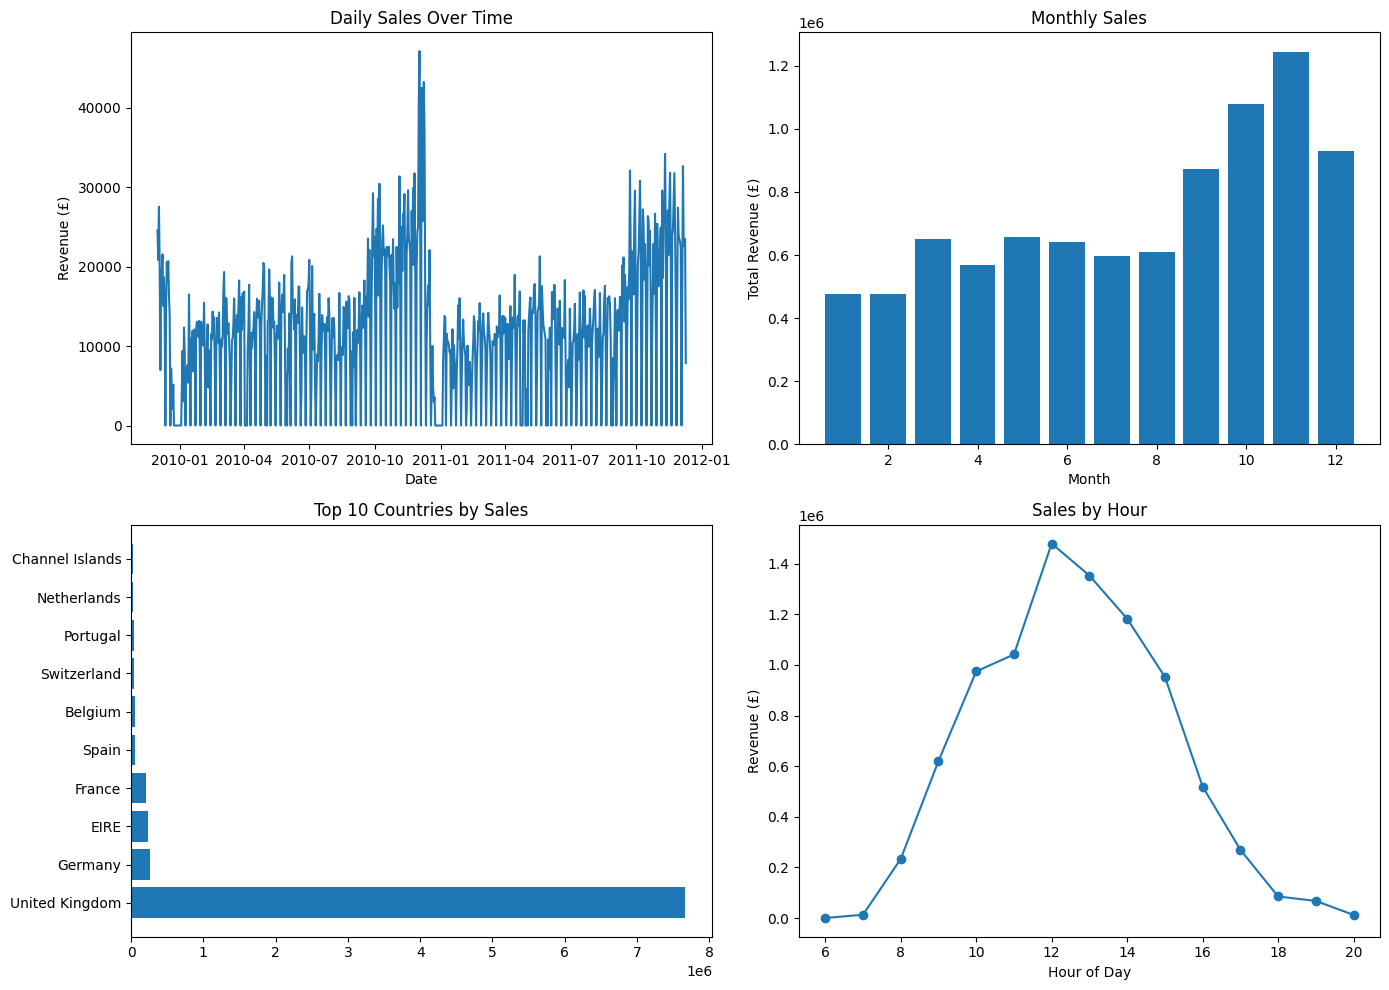

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily sales over time
axes[0,0].plot(daily_sales['ds'], daily_sales['y'])
axes[0,0].set_title('Daily Sales Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Revenue (£)')

# Sales by month
monthly = df_sales.groupby('Month')['TotalPrice'].sum()
axes[0,1].bar(monthly.index, monthly.values)
axes[0,1].set_title('Monthly Sales')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Total Revenue (£)')

# Top 10 countries
country_sales = df_sales.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
axes[1,0].barh(country_sales.index, country_sales.values)
axes[1,0].set_title('Top 10 Countries by Sales')

# Hourly distribution
hourly = df_sales.groupby('Hour')['TotalPrice'].sum()
axes[1,1].plot(hourly.index, hourly.values, marker='o')
axes[1,1].set_title('Sales by Hour')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../data/processed/eda_plots.png')
plt.show()